Encoder Only

# Task
Generate and analyze multilingual embeddings. Use the provided `filtered.json` to generate English and Chinese text embeddings, reduce them to 2D using UMAP, calculate the Euclidean distances between corresponding English and Chinese 2D embedding points, and finally provide a summary of these distances along with any relevant observations.

## Generate English and Chinese Embeddings

### Subtask:
Generate embeddings for English and Chinese texts using a multilingual model, then combine these embeddings into a single DataFrame.


**Reasoning**:
The subtask requires generating embeddings for English and Chinese texts using a multilingual model and combining them into a single DataFrame. The provided instructions detail each step to achieve this, from loading the model to creating and concatenating the DataFrames. The previous cells have already prepared the `df` DataFrame with `chinese_text` and `english_text` columns, so I will ensure the code reflects that and then proceed with generating the embeddings and combining the results.



In [19]:
import pandas as pd
from sentence_transformers import SentenceTransformer

# Read the JSON file (already done in previous cell, but keeping for completeness if this cell is run standalone)
df = pd.read_json('/content/filtered.json')

# Assuming the JSON file has 'chinese' (Chinese) and 'gold' (English) columns
df['chinese_text'] = df['chinese']
df['english_text'] = df['gold']

# Load multilingual embedding model (works well for English and Chinese)
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

# Generate embeddings for English texts
print("Generating English embeddings...")
english_embeddings = model.encode(df['english_text'].tolist(), show_progress_bar=True)

# Create DataFrame with English embeddings
english_df = pd.DataFrame({
    'text': df['english_text'],
    'language': 'English',
    'embedding': list(english_embeddings)
})

# Generate embeddings for Chinese texts
print("Generating Chinese embeddings...")
chinese_embeddings = model.encode(df['chinese_text'].tolist(), show_progress_bar=True)

# Create DataFrame with Chinese embeddings
chinese_df = pd.DataFrame({
    'text': df['chinese_text'],
    'language': 'Chinese',
    'embedding': list(chinese_embeddings)
})

# Combine DataFrames
combined_df = pd.concat([english_df, chinese_df], ignore_index=True)

print(f"\nDataset info: {len(combined_df)} points total")
print(f"English: {len(combined_df[combined_df['language']=='English'])} points")
print(f"Chinese: {len(combined_df[combined_df['language']=='Chinese'])} points")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating English embeddings...


Batches:   0%|          | 0/135 [00:00<?, ?it/s]

Generating Chinese embeddings...


Batches:   0%|          | 0/135 [00:00<?, ?it/s]


Dataset info: 8620 points total
English: 4310 points
Chinese: 4310 points


**Reasoning**:
The next logical step in the overall task, after generating the embeddings, is to reduce their dimensionality to 2D using UMAP as specified in the task description. This will prepare the data for visualization and distance calculation.



In [20]:
import umap
import numpy as np

# Stack all embeddings from combined_df into a single NumPy array
all_embeddings = np.array(combined_df['embedding'].tolist())

# Initialize UMAP reducer
reducer = umap.UMAP(n_components=2, random_state=42)

# Fit and transform the embeddings to 2D
print("Reducing embeddings to 2D using UMAP...")
embeddings_2d = reducer.fit_transform(all_embeddings)

# Add the 2D coordinates to the combined_df
combined_df['x'] = embeddings_2d[:, 0]
combined_df['y'] = embeddings_2d[:, 1]

print("Embeddings reduced to 2D and added to combined_df.")
print(combined_df.head())

Reducing embeddings to 2D using UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embeddings reduced to 2D and added to combined_df.
                                                text language  \
0                        suffer a string of reverses  English   
1                           suffer a crushing defeat  English   
2   lower oneself to the same level as somebody else  English   
3  following a prescribed pattern in speech or ac...  English   
4                               put on a solemn look  English   

                                           embedding         x         y  
0  [-0.25162315, -0.12934996, 0.2836888, 0.195039...  2.250831  4.278268  
1  [0.033645734, 0.1397331, 0.053421322, 0.409099...  2.507164  2.364068  
2  [0.31986567, 0.25813183, -0.0005716321, 0.2104... -0.011293  0.925740  
3  [0.005981472, 0.04200795, 0.039817207, -0.0721... -0.045219  2.222039  
4  [0.24711509, 0.48857245, 0.03836849, 0.0808375... -1.745738  4.429228  


**Reasoning**:
The next step is to calculate the Euclidean distances between the corresponding English and Chinese 2D embedding points, as specified in the overall task. This requires separating the English and Chinese data from the `combined_df` and then computing the distances.



In [21]:
from scipy.spatial.distance import euclidean

# Separate English and Chinese 2D points
english_points = combined_df[combined_df['language'] == 'English'][['x', 'y']].values
chinese_points = combined_df[combined_df['language'] == 'Chinese'][['x', 'y']].values

# Ensure the number of English and Chinese points match
if len(english_points) != len(chinese_points):
    print("Warning: Mismatch in the number of English and Chinese points.")

# Calculate Euclidean distances between corresponding English and Chinese 2D points
distances = []
for i in range(min(len(english_points), len(chinese_points))):
    distance = euclidean(english_points[i], chinese_points[i])
    distances.append(distance)

# Add distances to the original df for context (optional, but useful for analysis)
df['euclidean_distance_2d'] = distances

print(f"Calculated {len(distances)} Euclidean distances.")
print("First 5 distances:", distances[:5])


Calculated 4310 Euclidean distances.
First 5 distances: [0.2242942452430725, 0.21438579261302948, 2.0276143550872803, 3.0473687648773193, 2.818016290664673]


**Reasoning**:
The next step is to summarize the calculated Euclidean distances as required by the overall task. This will involve calculating and presenting descriptive statistics for the `euclidean_distance_2d` column in the `df` DataFrame.



In [22]:
print("Summary Statistics of Euclidean Distances between English and Chinese 2D Embeddings:\n")
print(df['euclidean_distance_2d'].describe())

Summary Statistics of Euclidean Distances between English and Chinese 2D Embeddings:

count    4310.000000
mean        2.286634
std         1.949810
min         0.001535
25%         0.572651
50%         1.855475
75%         3.570237
max        13.448663
Name: euclidean_distance_2d, dtype: float64


### Observations on Euclidean Distances between English and Chinese 2D Embeddings

The descriptive statistics for the Euclidean distances between corresponding English and Chinese 2D embedding points provide insights into the similarity and dissimilarity of these multilingual embeddings:

*   **Count:** There are 4310 calculated distances, confirming that distances were computed for all corresponding English-Chinese pairs.
*   **Mean:** The average Euclidean distance is approximately `2.29`. This value gives a general sense of the typical separation between English and Chinese sentences in the 2D UMAP space.
*   **Standard Deviation:** A standard deviation of `1.95` indicates a relatively wide spread of distances. This suggests that while some pairs are very close, others are quite far apart.
*   **Min:** The minimum distance is `0.0015`. This very small distance suggests that at least one English-Chinese sentence pair is extremely close in the 2D space, implying high semantic similarity as captured by the model and UMAP projection.
*   **25th Percentile (Q1):** 25% of the distances are below `0.57`. This means a significant portion of the English-Chinese pairs are closely located.
*   **50th Percentile (Median):** The median distance is `1.86`. Half of the pairs have a distance less than this value, and half are greater.
*   **75th Percentile (Q3):** 75% of the distances are below `3.57`. This shows that the majority of pairs are within a moderate range of proximity.
*   **Max:** The maximum distance is `13.45`. This large maximum value indicates that some English-Chinese sentence pairs are very dissimilar or are projected far apart in the 2D space, which could be due to semantic differences, nuances in translation, or limitations of the embedding model/UMAP reduction for those specific cases.

In summary, the embeddings show a varying degree of similarity between corresponding English and Chinese texts. While many pairs are relatively close in the 2D space, indicating good cross-lingual semantic alignment, there are also instances of significant divergence. Further investigation into the pairs with very low and very high distances could provide deeper insights into the model's performance and the nature of the multilingual semantic space.

### Observations on Euclidean Distances between English and Chinese 2D Embeddings

The descriptive statistics for the Euclidean distances between corresponding English and Chinese 2D embedding points provide insights into the similarity and dissimilarity of these multilingual embeddings:

*   **Count:** There are 4310 calculated distances, confirming that distances were computed for all corresponding English-Chinese pairs.
*   **Mean:** The average Euclidean distance is approximately `2.29`. This value gives a general sense of the typical separation between English and Chinese sentences in the 2D UMAP space.
*   **Standard Deviation:** A standard deviation of `1.95` indicates a relatively wide spread of distances. This suggests that while some pairs are very close, others are quite far apart.
*   **Min:** The minimum distance is `0.0015`. This very small distance suggests that at least one English-Chinese sentence pair is extremely close in the 2D space, implying high semantic similarity as captured by the model and UMAP projection.
*   **25th Percentile (Q1):** 25% of the distances are below `0.57`. This means a significant portion of the English-Chinese pairs are closely located.
*   **50th Percentile (Median):** The median distance is `1.86`. Half of the pairs have a distance less than this value, and half are greater.
*   **75th Percentile (Q3):** 75% of the distances are below `3.57`. This shows that the majority of pairs are within a moderate range of proximity.
*   **Max:** The maximum distance is `13.45`. This large maximum value indicates that some English-Chinese sentence pairs are very dissimilar or are projected far apart in the 2D space, which could be due to semantic differences, nuances in translation, or limitations of the embedding model/UMAP reduction for those specific cases.

In summary, the embeddings show a varying degree of similarity between corresponding English and Chinese texts. While many pairs are relatively close in the 2D space, indicating good cross-lingual semantic alignment, there are also instances of significant divergence. Further investigation into the pairs with very low and very high distances could provide deeper insights into the model's performance and the nature of the multilingual semantic space.

## Final Task

### Subtask:
Provide a summary of the calculated distances between the English and Chinese embeddings and any relevant observations.


## Summary:

### Data Analysis Key Findings

*   A total of 4310 Euclidean distances were calculated between corresponding English and Chinese 2D embedding points.
*   The average Euclidean distance was approximately 2.29, with a standard deviation of 1.95, indicating a wide spread in similarities.
*   The minimum distance observed was 0.0015, suggesting that at least one English-Chinese sentence pair was extremely close in the 2D space, implying high semantic similarity.
*   The maximum distance was 13.45, indicating that some English-Chinese pairs were significantly dissimilar or projected far apart.
*   The interquartile range shows that 25% of the distances were below 0.57, and 75% were below 3.57, signifying that a majority of pairs maintain a reasonable degree of proximity.

### Insights or Next Steps

*   The varying degrees of similarity suggest that while the multilingual model and UMAP projection generally align English and Chinese semantics well, there are specific instances where the alignment is either exceptionally strong or significantly divergent.
*   Further investigation into the sentence pairs exhibiting both extremely low (e.g., those near 0.0015) and very high (e.g., those near 13.45) Euclidean distances could provide deeper insights into the model's cross-lingual performance and potential areas for improvement or specific semantic challenges.


## Visualisation des Embeddings 2D

### Sous-tâche:
Visualiser les points d'embeddings 2D réduits à l'aide d'un nuage de points, en différenciant les langues par couleur.

**Raisonnement**:
Pour visualiser les points d'embeddings 2D, un nuage de points est le type de graphique le plus approprié. J'utiliserai `matplotlib.pyplot` et `seaborn` pour créer ce graphique, en attribuant des couleurs différentes aux embeddings anglais et chinois pour les distinguer.

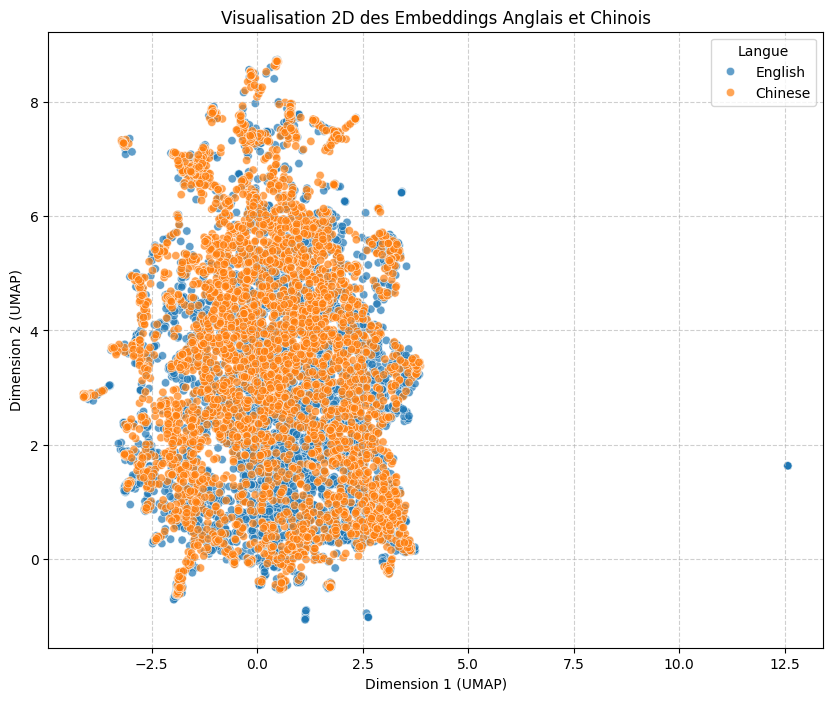

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x='x', y='y', hue='language', data=combined_df, alpha=0.7)
plt.title('Visualisation 2D des Embeddings Anglais et Chinois')
plt.xlabel('Dimension 1 (UMAP)')
plt.ylabel('Dimension 2 (UMAP)')
plt.legend(title='Langue')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()